In [17]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import random

In [18]:
#--- Random Seeding + Device Checking ---
def set_seed(seed):
    """
    Set all random seeds for reproducibility.
    This ensures consistent data splits and weight initialization.
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    # For deterministic behavior (slower but reproducible)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Initial seed setup
set_seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [19]:
#--- Creating a custom dataset class ---
class SharkFluorescenceDataset(Dataset):
    def __init__(self, csv_path, augment=False, mean=None, std=None):
        # Load CSV
        self.data = pd.read_csv(csv_path)
        
        # Extract species names (labels) from first column
        self.species = self.data.iloc[:, 0].values
        
        # Extract fluorescence values (all columns except first)
        # Shape: (num_samples, num_time_steps)
        self.fluorescence = self.data.iloc[:, 1:].values.astype(np.float32)

        # Normalization
        if mean is None or std is None:
            # Calculate mean and std from this data (for training set)
            self.mean = self.fluorescence.mean()
            self.std = self.fluorescence.std()
        else:
            # Use provided mean and std (for val/test sets)
            self.mean = mean
            self.std = std
        
        # Apply normalization: (x - mean) / std
        self.fluorescence = (self.fluorescence - self.mean) / self.std
        
        # Encode species names to numeric labels
        self.label_encoder = LabelEncoder()
        self.labels = self.label_encoder.fit_transform(self.species)
        
        self.num_classes = len(self.label_encoder.classes_)
        self.augment = augment
        
        print(f"Dataset loaded: {len(self.labels)} samples")
        print(f"Number of species: {self.num_classes}")
        print(f"Time series length: {self.fluorescence.shape[1]}")
        print(f"Augmentation: {'Enabled' if augment else 'Disabled'}")
        print(f"Data normalized with mean={self.mean:.6f}, std={self.std:.6f}")
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        # Get fluorescence values and add channel dimension
        # Shape: (1, num_time_steps) - 1D conv expects (channels, length)
        x = torch.FloatTensor(self.fluorescence[idx]).unsqueeze(0)

        # Apply augmentation if enabled
        if self.augment:
            # Small random noise
            noise = torch.randn_like(x) * 0.01
            x = x + noise
            # Random scaling
            scale = 1 + torch.FloatTensor([np.random.uniform(-0.05, 0.05)])
            x = x * scale
            # Random shift along time axis (small horizontal shift)
            shift = np.random.randint(-5, 6)
            if shift != 0:
                x = torch.roll(x, shifts=shift, dims=1)
        
        # Get label
        y = torch.LongTensor([self.labels[idx]])[0]
        
        return x, y

In [20]:
# --- Residual Block Definition ---
class ResidualBlock1D(nn.Module):
    """
    1D Residual Block with two convolutional layers and a skip connection.
    This allows the network to learn residual functions, making training deeper networks easier.
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, downsample=None):
        super(ResidualBlock1D, self).__init__()
        
        # First convolutional layer
        self.conv1 = nn.Conv1d(
            in_channels, 
            out_channels, 
            kernel_size=kernel_size, 
            stride=stride, 
            padding=kernel_size//2,  # Same padding to maintain dimensions
            bias=False
        )
        self.bn1 = nn.BatchNorm1d(out_channels)  # Normalize activations
        
        # Second convolutional layer
        self.conv2 = nn.Conv1d(
            out_channels, 
            out_channels, 
            kernel_size=kernel_size, 
            stride=1, 
            padding=kernel_size//2,
            bias=False
        )
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        # ReLU activation function
        self.relu = nn.ReLU(inplace=True)
        
        # Downsample layer for skip connection if dimensions don't match
        self.downsample = downsample
    
    def forward(self, x):
        # Store input for skip connection
        identity = x
        
        # First conv -> batch norm -> relu
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        # Second conv -> batch norm
        out = self.conv2(out)
        out = self.bn2(out)
        
        # Apply downsample to identity if needed (to match dimensions)
        if self.downsample is not None:
            identity = self.downsample(x)
        
        # Add skip connection (residual)
        out += identity
        
        # Final activation
        out = self.relu(out)
        
        return out

In [21]:
#--- ResNet1D Definition [with Dropout] ---
class ResNet1D(nn.Module):
    """
    1D ResNet for time-series classification.
    Architecture:
    - Initial conv layer
    - Multiple residual blocks organized in layers
    - Global average pooling
    - Fully connected layer for classification
    """
    def __init__(self, num_classes, input_channels=1, initial_filters=64, dropout=0.65):
        super(ResNet1D, self).__init__()
        
        # Initial convolutional layer
        self.conv1 = nn.Conv1d(
            input_channels, 
            initial_filters, 
            kernel_size=7, 
            stride=2, 
            padding=3, 
            bias=False
        )
        self.bn1 = nn.BatchNorm1d(initial_filters)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        
        # Residual layers (ResNet-18 style: 2 blocks per layer)
        self.layer1 = self._make_layer(initial_filters, initial_filters, blocks=2)
        self.layer2 = self._make_layer(initial_filters, initial_filters*2, blocks=2, stride=2)
        self.layer3 = self._make_layer(initial_filters*2, initial_filters*4, blocks=2, stride=2)
        self.layer4 = self._make_layer(initial_filters*4, initial_filters*8, blocks=2, stride=2)
        
        # Global average pooling - reduces time dimension to 1
        self.avgpool = nn.AdaptiveAvgPool1d(1)

        # Dropout layer: prevents overfitting
        self.dropout = nn.Dropout(dropout)
        
        # Fully connected layer for classification
        self.fc = nn.Linear(initial_filters*8, num_classes)
    
    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        """
        Create a layer consisting of multiple residual blocks.
        """
        downsample = None
        
        # If dimensions change, we need a downsample layer for the skip connection
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        
        layers = []
        # First block (may downsample)
        layers.append(ResidualBlock1D(in_channels, out_channels, stride=stride, downsample=downsample))
        
        # Remaining blocks (no downsampling)
        for _ in range(1, blocks):
            layers.append(ResidualBlock1D(out_channels, out_channels))
        
        return nn.Sequential(*layers)
    
    def forward(self, x):
        # Initial conv layer
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        # Residual layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        # Global pooling and flatten
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        
        # Classification layer
        x = self.fc(x)
        
        return x

In [22]:
#--- Training Function ---
def train_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train the model for one epoch.
    """
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in dataloader:
        # Move data to device (GPU/CPU)
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

In [23]:
#--- Evaluation Function ---
def evaluate(model, dataloader, criterion, device):
    """
    Evaluate the model on a dataset.
    """
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    all_predictions = []
    all_labels = []
    
    # No gradient computation during evaluation
    with torch.no_grad():
        for inputs, labels in dataloader:
            # Move data to device
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    total = len(all_labels)
    epoch_loss = running_loss / total
    epoch_acc = 100 * accuracy_score(all_labels, all_predictions)
    
    return epoch_loss, epoch_acc, all_predictions, all_labels

In [26]:
#--- Dataset + Split (change when needed) ---
# Configuration
NUM_SPLITS = 5  # Number of different data splits to try (5-10 recommended)
SEEDS = [42, 123, 456, 789, 2024][:NUM_SPLITS]  # Different seeds for different splits

# Store all split configurations
splits_config = []

print("="*70)
print(f"CREATING {NUM_SPLITS} DIFFERENT DATA SPLITS")
print("="*70)
print(f"Seeds: {SEEDS}")
print("="*70)

for split_idx, seed in enumerate(SEEDS):
    print(f"\nCreating Split {split_idx + 1}/{NUM_SPLITS} with seed {seed}...")
    
    # Set seed for this split
    set_seed(seed)
    
    # Load full dataset
    full_dataset = SharkFluorescenceDataset('../../data/shark_dataset.csv', augment=False)
    
    # Get normalization parameters
    train_mean = full_dataset.mean
    train_std = full_dataset.std
    
    # Split dataset: 70% train, 15% validation, 15% test
    train_size = int(0.7 * len(full_dataset))
    val_size = int(0.15 * len(full_dataset))
    test_size = len(full_dataset) - train_size - val_size
    
    # Create splits with current seed
    train_indices, val_indices, test_indices = random_split(
        range(len(full_dataset)), 
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(seed)
    )
    
    # Create datasets
    train_dataset_full = SharkFluorescenceDataset('../../data/shark_dataset.csv', augment=True, mean=train_mean, std=train_std)
    train_dataset = torch.utils.data.Subset(train_dataset_full, train_indices.indices)
    
    eval_dataset_full = SharkFluorescenceDataset('../../data/shark_dataset.csv', augment=False, mean=train_mean, std=train_std)
    val_dataset = torch.utils.data.Subset(eval_dataset_full, val_indices.indices)
    test_dataset = torch.utils.data.Subset(eval_dataset_full, test_indices.indices)
    
    # Create dataloaders
    batch_size = 16
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Store configuration
    splits_config.append({
        'seed': seed,
        'full_dataset': full_dataset,
        'train_loader': train_loader,
        'val_loader': val_loader,
        'test_loader': test_loader,
        'train_size': len(train_dataset),
        'val_size': len(val_dataset),
        'test_size': len(test_dataset)
    })
    
    print(f"  Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

print(f"\n{'='*70}")
print(f"All {NUM_SPLITS} data splits created successfully!")
print(f"{'='*70}")

CREATING 5 DIFFERENT DATA SPLITS
Seeds: [42, 123, 456, 789, 2024]

Creating Split 1/5 with seed 42...
Dataset loaded: 651 samples
Number of species: 57
Time series length: 3475
Augmentation: Disabled
Data normalized with mean=0.010646, std=0.013126
Dataset loaded: 651 samples
Number of species: 57
Time series length: 3475
Augmentation: Enabled
Data normalized with mean=0.010646, std=0.013126
Dataset loaded: 651 samples
Number of species: 57
Time series length: 3475
Augmentation: Disabled
Data normalized with mean=0.010646, std=0.013126
  Train: 455 | Val: 97 | Test: 99

Creating Split 2/5 with seed 123...
Dataset loaded: 651 samples
Number of species: 57
Time series length: 3475
Augmentation: Disabled
Data normalized with mean=0.010646, std=0.013126
Dataset loaded: 651 samples
Number of species: 57
Time series length: 3475
Augmentation: Enabled
Data normalized with mean=0.010646, std=0.013126
Dataset loaded: 651 samples
Number of species: 57
Time series length: 3475
Augmentation: Disab


MULTI-SPLIT TRAINING PIPELINE
Training model on 5 different data splits
This ensures results are consistent across different configurations

TRAINING SPLIT 1/5 - SEED: 42

Model architecture:
ResNet1D(
  (conv1): Conv1d(1, 64, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (1): ResidualBlock1D(
      (conv1): Conv1d(64, 64, kern

C:\Users\thepa\AppData\Local\Temp\ipykernel_22236\3392308323.py:213: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot([all_results['train_acc'], all_results['val_acc'], all_results['test_acc']],


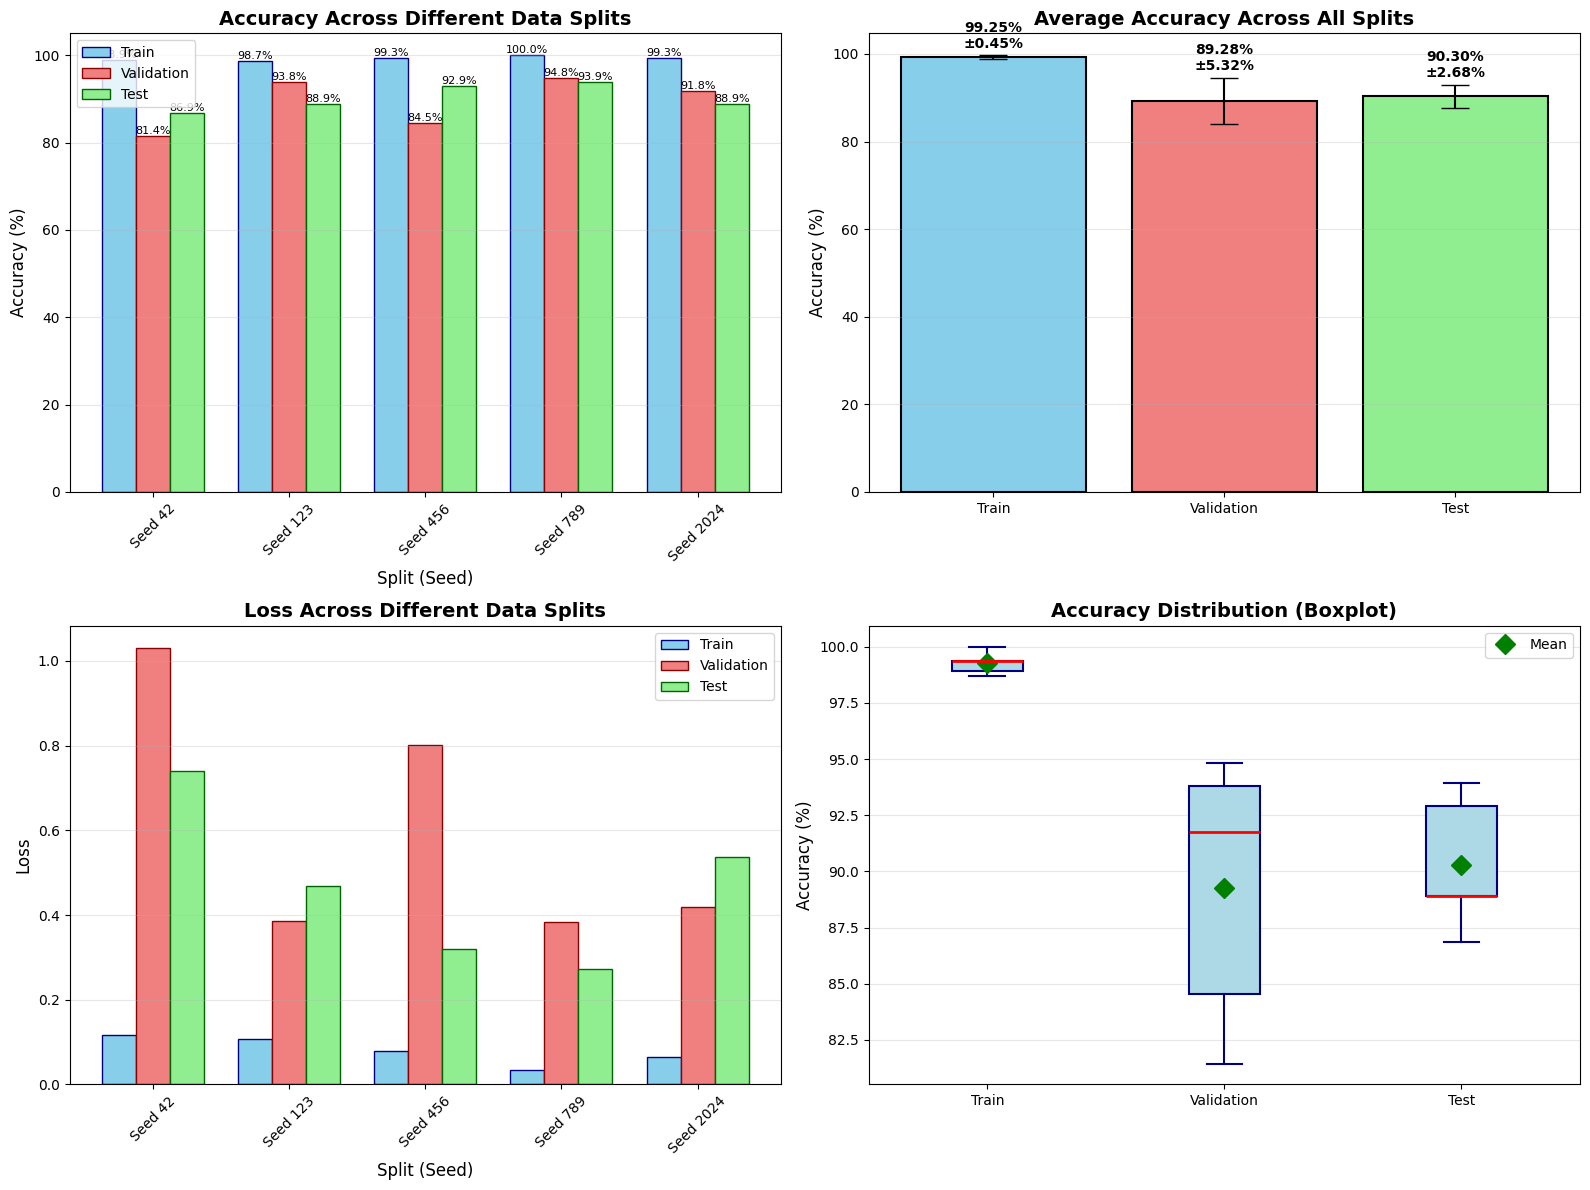


Multi-split visualization saved as 'multi_split_results.png'


In [27]:
# Store results for all splits
all_results = {
    'seed': [],
    'train_acc': [],
    'val_acc': [],
    'test_acc': [],
    'train_loss': [],
    'val_loss': [],
    'test_loss': []
}

print("\n" + "="*70)
print(f"MULTI-SPLIT TRAINING PIPELINE")
print("="*70)
print(f"Training model on {NUM_SPLITS} different data splits")
print(f"This ensures results are consistent across different configurations")
print("="*70)

for split_idx, split_config in enumerate(splits_config):
    seed = split_config['seed']
    train_loader = split_config['train_loader']
    val_loader = split_config['val_loader']
    test_loader = split_config['test_loader']
    full_dataset = split_config['full_dataset']
    
    print(f"\n{'='*70}")
    print(f"TRAINING SPLIT {split_idx + 1}/{NUM_SPLITS} - SEED: {seed}")
    print(f"{'='*70}")
    
    # Set seed for this training run
    set_seed(seed)
    
    #--- Model, Loss, Optimizer, Scheduler ---
    model = ResNet1D(
        num_classes=full_dataset.num_classes,
        dropout=0.5
    ).to(device)
    
    # Loss function (Cross Entropy for multi-class classification)
    criterion = nn.CrossEntropyLoss()
    
    # Optimizer (AdamW with weight decay for regularization)
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.0001)
    
    # Learning rate scheduler (reduce LR when validation loss plateaus)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=5
    )
    
    # Print model summary (only for first split to avoid spam)
    if split_idx == 0:
        print(f"\nModel architecture:")
        print(model)
        print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
        print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}\n")
    
    #--- Training Loop ---
    num_epochs = 100
    best_val_acc = 0.0
    min_val_loss = float('inf')
    patience_early_stop = 15
    epochs_no_improve = 0
    
    print(f"Starting training for split {split_idx + 1}...")
    
    for epoch in range(num_epochs):
        # Train for one epoch
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Evaluate on validation set
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        
        # Update learning rate based on validation loss
        scheduler.step(val_loss)
        
        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1}/{num_epochs}] "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        # Save best model based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_resnet1d_seed{seed}.pth')
        
        # Early stopping check based on validation loss
        if val_loss < min_val_loss:
            min_val_loss = val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        # Trigger early stopping
        if epochs_no_improve == patience_early_stop:
            print(f"  Early stopping at epoch {epoch+1}")
            break
    
    print(f"Training complete for split {split_idx + 1}. Total epochs: {epoch + 1}")
    
    #--- Load Best Model and Evaluate on All Sets ---
    model.load_state_dict(torch.load(f'best_resnet1d_seed{seed}.pth'))
    
    # Evaluate on train set
    train_loss_final, train_acc_final, _, _ = evaluate(model, train_loader, criterion, device)
    
    # Evaluate on validation set
    val_loss_final, val_acc_final, _, _ = evaluate(model, val_loader, criterion, device)
    
    # Evaluate on test set
    test_loss_final, test_acc_final, _, _ = evaluate(model, test_loader, criterion, device)
    
    # Store results
    all_results['seed'].append(seed)
    all_results['train_acc'].append(train_acc_final)
    all_results['val_acc'].append(val_acc_final)
    all_results['test_acc'].append(test_acc_final)
    all_results['train_loss'].append(train_loss_final)
    all_results['val_loss'].append(val_loss_final)
    all_results['test_loss'].append(test_loss_final)
    
    print(f"\nSplit {split_idx + 1} Final Results:")
    print(f"  Train Acc: {train_acc_final:.2f}% | Val Acc: {val_acc_final:.2f}% | Test Acc: {test_acc_final:.2f}%")

#--- Calculate Average Results Across All Splits ---
print("\n" + "="*70)
print("AVERAGE RESULTS ACROSS ALL SPLITS")
print("="*70)
print(f"\nTrain Accuracy: {np.mean(all_results['train_acc']):.2f}% ± {np.std(all_results['train_acc']):.2f}%")
print(f"Val Accuracy:   {np.mean(all_results['val_acc']):.2f}% ± {np.std(all_results['val_acc']):.2f}%")
print(f"Test Accuracy:  {np.mean(all_results['test_acc']):.2f}% ± {np.std(all_results['test_acc']):.2f}%")
print(f"\nTrain Loss: {np.mean(all_results['train_loss']):.4f} ± {np.std(all_results['train_loss']):.4f}")
print(f"Val Loss:   {np.mean(all_results['val_loss']):.4f} ± {np.std(all_results['val_loss']):.4f}")
print(f"Test Loss:  {np.mean(all_results['test_loss']):.4f} ± {np.std(all_results['test_loss']):.4f}")

# Create results DataFrame
results_df = pd.DataFrame(all_results)
print("\n" + "="*70)
print("DETAILED RESULTS PER SPLIT")
print("="*70)
print(results_df.to_string(index=False))

# Save results to CSV
results_df.to_csv('multi_split_results.csv', index=False)
print("\nResults saved to 'multi_split_results.csv'")
"""
Visualize the consistency of results across different data splits.
This helps verify that improvements are real and not due to lucky splits.
"""

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Accuracy comparison across splits
ax1 = axes[0, 0]
x = np.arange(len(SEEDS))
width = 0.25

bars1 = ax1.bar(x - width, all_results['train_acc'], width, label='Train', color='skyblue', edgecolor='navy')
bars2 = ax1.bar(x, all_results['val_acc'], width, label='Validation', color='lightcoral', edgecolor='darkred')
bars3 = ax1.bar(x + width, all_results['test_acc'], width, label='Test', color='lightgreen', edgecolor='darkgreen')

ax1.set_xlabel('Split (Seed)', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Accuracy Across Different Data Splits', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f'Seed {s}' for s in SEEDS], rotation=45)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

# Plot 2: Average accuracy with std bars
ax2 = axes[0, 1]
means = [np.mean(all_results['train_acc']), np.mean(all_results['val_acc']), np.mean(all_results['test_acc'])]
stds = [np.std(all_results['train_acc']), np.std(all_results['val_acc']), np.std(all_results['test_acc'])]
labels = ['Train', 'Validation', 'Test']
colors = ['skyblue', 'lightcoral', 'lightgreen']

bars = ax2.bar(labels, means, yerr=stds, capsize=10, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Average Accuracy Across All Splits', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar, mean, std in zip(bars, means, stds):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + std + 1,
            f'{mean:.2f}%\n±{std:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 3: Loss comparison across splits
ax3 = axes[1, 0]
bars1 = ax3.bar(x - width, all_results['train_loss'], width, label='Train', color='skyblue', edgecolor='navy')
bars2 = ax3.bar(x, all_results['val_loss'], width, label='Validation', color='lightcoral', edgecolor='darkred')
bars3 = ax3.bar(x + width, all_results['test_loss'], width, label='Test', color='lightgreen', edgecolor='darkgreen')

ax3.set_xlabel('Split (Seed)', fontsize=12)
ax3.set_ylabel('Loss', fontsize=12)
ax3.set_title('Loss Across Different Data Splits', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([f'Seed {s}' for s in SEEDS], rotation=45)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Test accuracy distribution
ax4 = axes[1, 1]
ax4.boxplot([all_results['train_acc'], all_results['val_acc'], all_results['test_acc']], 
            labels=['Train', 'Validation', 'Test'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', edgecolor='navy', linewidth=1.5),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='navy', linewidth=1.5),
            capprops=dict(color='navy', linewidth=1.5))

ax4.set_ylabel('Accuracy (%)', fontsize=12)
ax4.set_title('Accuracy Distribution (Boxplot)', fontsize=14, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# Add mean markers
for i, (label, data) in enumerate(zip(['Train', 'Val', 'Test'], 
                                       [all_results['train_acc'], all_results['val_acc'], all_results['test_acc']])):
    mean_val = np.mean(data)
    ax4.plot(i+1, mean_val, 'D', markersize=10, color='green', label='Mean' if i == 0 else '')

ax4.legend()

plt.tight_layout()
plt.savefig('multi_split_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMulti-split visualization saved as 'multi_split_results.png'")

In [28]:
# #--- Training loop ---
# num_epochs = 100
# best_val_acc = 0.0
# train_losses = []
# val_losses = []
# train_accs = []
# val_accs = []
# patience = 15
# epochs_no_improve = 0
# min_val_loss = float('inf')

# print("\nStarting training...")
# for epoch in range(num_epochs):
#     # Train for one epoch
#     train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
#     # Evaluate on validation set
#     val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    
#     # Update learning rate based on validation loss
#     scheduler.step(val_loss)
    
#     # Store metrics
#     train_losses.append(train_loss)
#     val_losses.append(val_loss)
#     train_accs.append(train_acc)
#     val_accs.append(val_acc)
    
#     # Print progress
#     print(f"Epoch [{epoch+1}/{num_epochs}] "
#           f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
#           f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
#     # Save best model
#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         torch.save(model.state_dict(), 'best_resnet1d_shark.pth')
#         print(f"  -> New best model saved!")

#     # Early stopping
#     if val_loss < min_val_loss:
#         min_val_loss = val_loss
#         epochs_no_improve = 0
#     else:
#         epochs_no_improve += 1

#     if epochs_no_improve == patience:
#         print(f"\nEarly stopping triggered after {epoch+1} epochs")
#         print(f"No improvement for {patience} consecutive epochs")
#         break

# print(f"\nTraining complete! Best validation accuracy: {best_val_acc:.2f}%")
# print(f"Total epochs trained: {len(train_losses)}")

In [42]:
#--- Evaluation on test set ---
seed_to_use = 789
split_config = [s for s in splits_config if s['seed'] == seed_to_use][0]

# Get the dataset and loaders
full_dataset = split_config['full_dataset']
test_loader = split_config['test_loader']

# Load the model
model = ResNet1D(num_classes=full_dataset.num_classes, dropout=0.5).to(device)
model.load_state_dict(torch.load('best_resnet1d_seed789.pth'))

criterion = nn.CrossEntropyLoss()

# Evaluate on test set
test_loss, test_acc, test_predictions, test_labels = evaluate(
    model, test_loader, criterion, device
)

print(f"\n{'='*60}")
print(f"TEST SET RESULTS")
print(f"{'='*60}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"\nClassification Report:")

# Get unique labels that actually appear in test set
unique_labels = sorted(list(set(test_labels)))
# target_names_test = [dataset.label_encoder.classes_[i] for i in unique_labels]
target_names_test = [full_dataset.label_encoder.classes_[i] for i in unique_labels]
print(classification_report(
    test_labels, 
    test_predictions,
    labels=unique_labels,
    target_names=target_names_test
))


TEST SET RESULTS
Test Loss: 0.2733
Test Accuracy: 93.94%

Classification Report:
                            precision    recall  f1-score   support

  Atlantic Sharpnose shark       0.00      0.00      0.00         1
      Blackchin guitarfish       1.00      1.00      1.00         3
           Blacknose shark       0.00      0.00      0.00         1
            Blacktip shark       1.00      1.00      1.00         4
                Blue shark       1.00      1.00      1.00         4
          Bonnethead shark       0.00      0.00      0.00         1
  Brownbanded bamboo shark       1.00      0.50      0.67         2
                Bull shark       0.80      1.00      0.89         4
      Caribbean reef shark       1.00      1.00      1.00         3
     Common thresher shark       1.00      1.00      1.00         2
              Copper shark       1.00      1.00      1.00         4
               Dusky shark       0.67      1.00      0.80         2
           Finetooth shark       

c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [35]:
best_split_idx = np.argmax(all_results['test_acc'])
worst_split_idx = np.argmin(all_results['test_acc'])

best_seed = SEEDS[best_split_idx]
print(f"\n{'='*70}")
print(f"LOADING BEST MODEL (Seed {best_seed}) FOR DETAILED ANALYSIS")
print(f"{'='*70}")

# Recreate the best split
set_seed(best_seed)
full_dataset = SharkFluorescenceDataset('../../data/shark_dataset.csv', augment=False)
train_mean = full_dataset.mean
train_std = full_dataset.std

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_indices, val_indices, test_indices = random_split(
    range(len(full_dataset)), 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(best_seed)
)

eval_dataset_full = SharkFluorescenceDataset('../../data/shark_dataset.csv', augment=False, mean=train_mean, std=train_std)
test_dataset = torch.utils.data.Subset(eval_dataset_full, test_indices.indices)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Load best model
model_best = ResNet1D(num_classes=full_dataset.num_classes, dropout=0.5).to(device)
model_best.load_state_dict(torch.load(f'best_resnet1d_seed{best_seed}.pth'))

# Evaluate
criterion = nn.CrossEntropyLoss()
test_loss, test_acc, test_predictions, test_labels = evaluate(
    model_best, test_loader, criterion, device
)

print(f"\nBest Model Test Results:")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# Classification report
print(f"\nClassification Report (Best Model):")
unique_labels = sorted(list(set(test_labels)))
target_names_test = [full_dataset.label_encoder.classes_[i] for i in unique_labels]
print(classification_report(
    test_labels, 
    test_predictions,
    labels=unique_labels,
    target_names=target_names_test
))


LOADING BEST MODEL (Seed 789) FOR DETAILED ANALYSIS
Dataset loaded: 651 samples
Number of species: 57
Time series length: 3475
Augmentation: Disabled
Data normalized with mean=0.010646, std=0.013126
Dataset loaded: 651 samples
Number of species: 57
Time series length: 3475
Augmentation: Disabled
Data normalized with mean=0.010646, std=0.013126

Best Model Test Results:
Test Accuracy: 93.94%
Test Loss: 0.2733

Classification Report (Best Model):
                            precision    recall  f1-score   support

  Atlantic Sharpnose shark       0.00      0.00      0.00         1
      Blackchin guitarfish       1.00      1.00      1.00         3
           Blacknose shark       0.00      0.00      0.00         1
            Blacktip shark       1.00      1.00      1.00         4
                Blue shark       1.00      1.00      1.00         4
          Bonnethead shark       0.00      0.00      0.00         1
  Brownbanded bamboo shark       1.00      0.50      0.67         2
     

c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

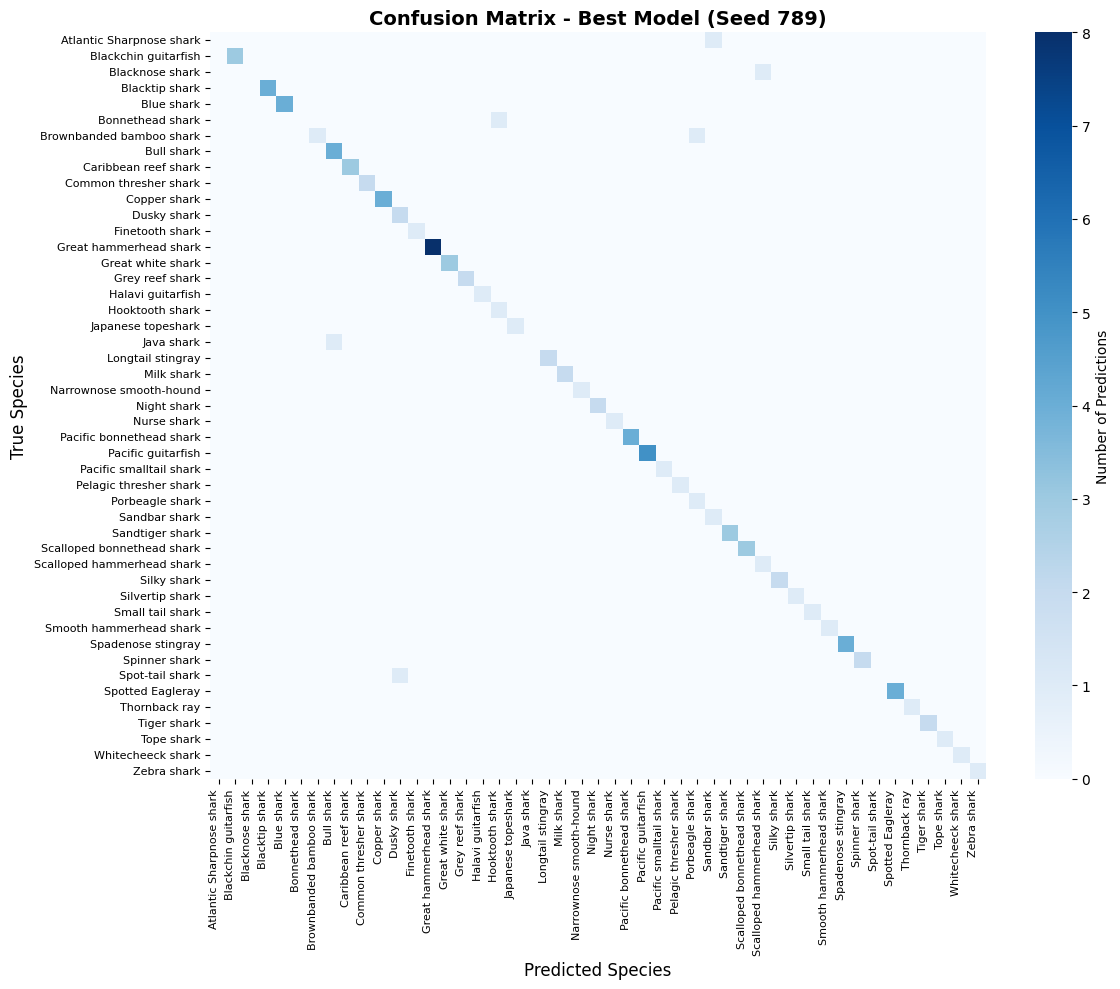

Confusion matrix saved as 'confusion_matrix.png'


In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get confusion matrix for test set
cm = confusion_matrix(test_labels, test_predictions)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
            xticklabels=target_names_test, 
            yticklabels=target_names_test,
            cbar_kws={'label': 'Number of Predictions'})
plt.xlabel('Predicted Species', fontsize=12)
plt.ylabel('True Species', fontsize=12)
plt.title(f'Confusion Matrix - Best Model (Seed {best_seed})', fontsize=14, fontweight='bold')
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix saved as 'confusion_matrix.png'")


TOP 5 BEST PERFORMING SPECIES
             Species  F1-Score  Precision  Recall  Support
Blackchin guitarfish       1.0        1.0     1.0        3
          Blue shark       1.0        1.0     1.0        4
      Blacktip shark       1.0        1.0     1.0        4
     Finetooth shark       1.0        1.0     1.0        1
        Copper shark       1.0        1.0     1.0        4

BOTTOM 5 WORST PERFORMING SPECIES
                 Species  F1-Score  Precision  Recall  Support
        Bonnethead shark       0.0        0.0     0.0        1
         Blacknose shark       0.0        0.0     0.0        1
Atlantic Sharpnose shark       0.0        0.0     0.0        1
              Java shark       0.0        0.0     0.0        1
         Spot-tail shark       0.0        0.0     0.0        1


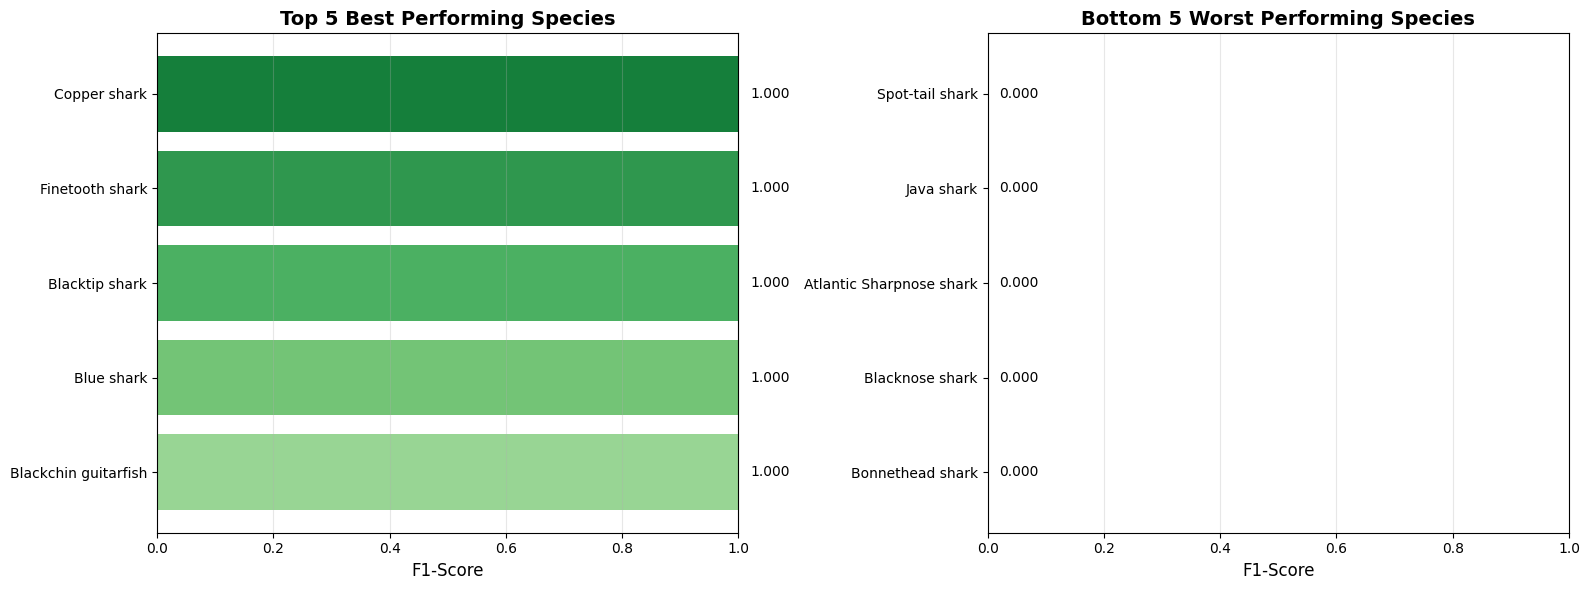


Species performance plot saved as 'species_performance.png'


In [37]:
from sklearn.metrics import precision_recall_fscore_support

# Calculate per-class metrics (precision, recall, f1-score)
precision, recall, f1, support = precision_recall_fscore_support(
    test_labels, 
    test_predictions, 
    labels=unique_labels,
    zero_division=0
)

# Create dataframe with species performance
species_performance = pd.DataFrame({
    'Species': target_names_test,
    'F1-Score': f1,
    'Precision': precision,
    'Recall': recall,
    'Support': support
})

# Sort by F1-score
species_performance = species_performance.sort_values('F1-Score', ascending=False)

# Get top 5 and bottom 5
top_5 = species_performance.head(5)
bottom_5 = species_performance.tail(5)

print("\n" + "="*70)
print("TOP 5 BEST PERFORMING SPECIES")
print("="*70)
print(top_5.to_string(index=False))

print("\n" + "="*70)
print("BOTTOM 5 WORST PERFORMING SPECIES")
print("="*70)
print(bottom_5.to_string(index=False))

# Plot top 5 and bottom 5
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 5
top_5_sorted = top_5.sort_values('F1-Score', ascending=True)
colors_top = plt.cm.Greens(np.linspace(0.4, 0.8, len(top_5_sorted)))
ax1.barh(range(len(top_5_sorted)), top_5_sorted['F1-Score'], color=colors_top)
ax1.set_yticks(range(len(top_5_sorted)))
ax1.set_yticklabels(top_5_sorted['Species'], fontsize=10)
ax1.set_xlabel('F1-Score', fontsize=12)
ax1.set_title('Top 5 Best Performing Species', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(top_5_sorted['F1-Score']):
    ax1.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=10)

# Bottom 5
bottom_5_sorted = bottom_5.sort_values('F1-Score', ascending=True)
colors_bottom = plt.cm.Reds(np.linspace(0.4, 0.8, len(bottom_5_sorted)))
ax2.barh(range(len(bottom_5_sorted)), bottom_5_sorted['F1-Score'], color=colors_bottom)
ax2.set_yticks(range(len(bottom_5_sorted)))
ax2.set_yticklabels(bottom_5_sorted['Species'], fontsize=10)
ax2.set_xlabel('F1-Score', fontsize=12)
ax2.set_title('Bottom 5 Worst Performing Species', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 1)
ax2.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(bottom_5_sorted['F1-Score']):
    ax2.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('species_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSpecies performance plot saved as 'species_performance.png'")